In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import missingno as ms

## DATA PROFILING

In [2]:
dt=pd.read_csv("Churn Modeling.csv")

In [3]:
dt.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(dt.columns)
print(len(dt.columns))

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
14


In [5]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
dt.shape

(10000, 14)

In [7]:
dt.describe(include="all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [8]:
dt.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [9]:
# summerry of mean median and mode

summery =pd.DataFrame({"means":dt.mean(numeric_only=True),"median":dt.median(numeric_only=True),"mode":dt.mode().iloc[0]})
summery

,means,median,mode
Age,3.892180e+01,3.700000e+01,37.0
Balance,7.648589e+04,9.719854e+04,0.0
CreditScore,6.505288e+02,6.520000e+02,850.0
CustomerId,1.569094e+07,1.569074e+07,15565701
EstimatedSalary,1.000902e+05,1.001939e+05,24924.92
Exited,2.037000e-01,0.000000e+00,0.0
Gender,NaN,NaN,Male
Geography,NaN,NaN,France
HasCrCard,7.055000e-01,1.000000e+00,1.0
IsActiveMember,5.151000e-01,1.000000e+00,1.0


In [10]:
# checking skewness with mean and mode
summery["skew"]= summery.apply(lambda x: "Right_skewed" if x["means"]>x["median"] else "Left_Skewed" if x["means"]<x["median"] else "Normal",axis=1)
print(summery)


                        means        median      mode          skew
Age              3.892180e+01  3.700000e+01      37.0  Right_skewed
Balance          7.648589e+04  9.719854e+04       0.0   Left_Skewed
CreditScore      6.505288e+02  6.520000e+02     850.0   Left_Skewed
CustomerId       1.569094e+07  1.569074e+07  15565701  Right_skewed
EstimatedSalary  1.000902e+05  1.001939e+05  24924.92   Left_Skewed
Exited           2.037000e-01  0.000000e+00       0.0  Right_skewed
Gender                    NaN           NaN      Male        Normal
Geography                 NaN           NaN    France        Normal
HasCrCard        7.055000e-01  1.000000e+00       1.0   Left_Skewed
IsActiveMember   5.151000e-01  1.000000e+00       1.0   Left_Skewed
NumOfProducts    1.530200e+00  1.000000e+00       1.0  Right_skewed
RowNumber        5.000500e+03  5.000500e+03         1        Normal
Surname                   NaN           NaN     Smith        Normal
Tenure           5.012800e+00  5.000000e+00     

In [11]:
# check for missing values 
dt.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

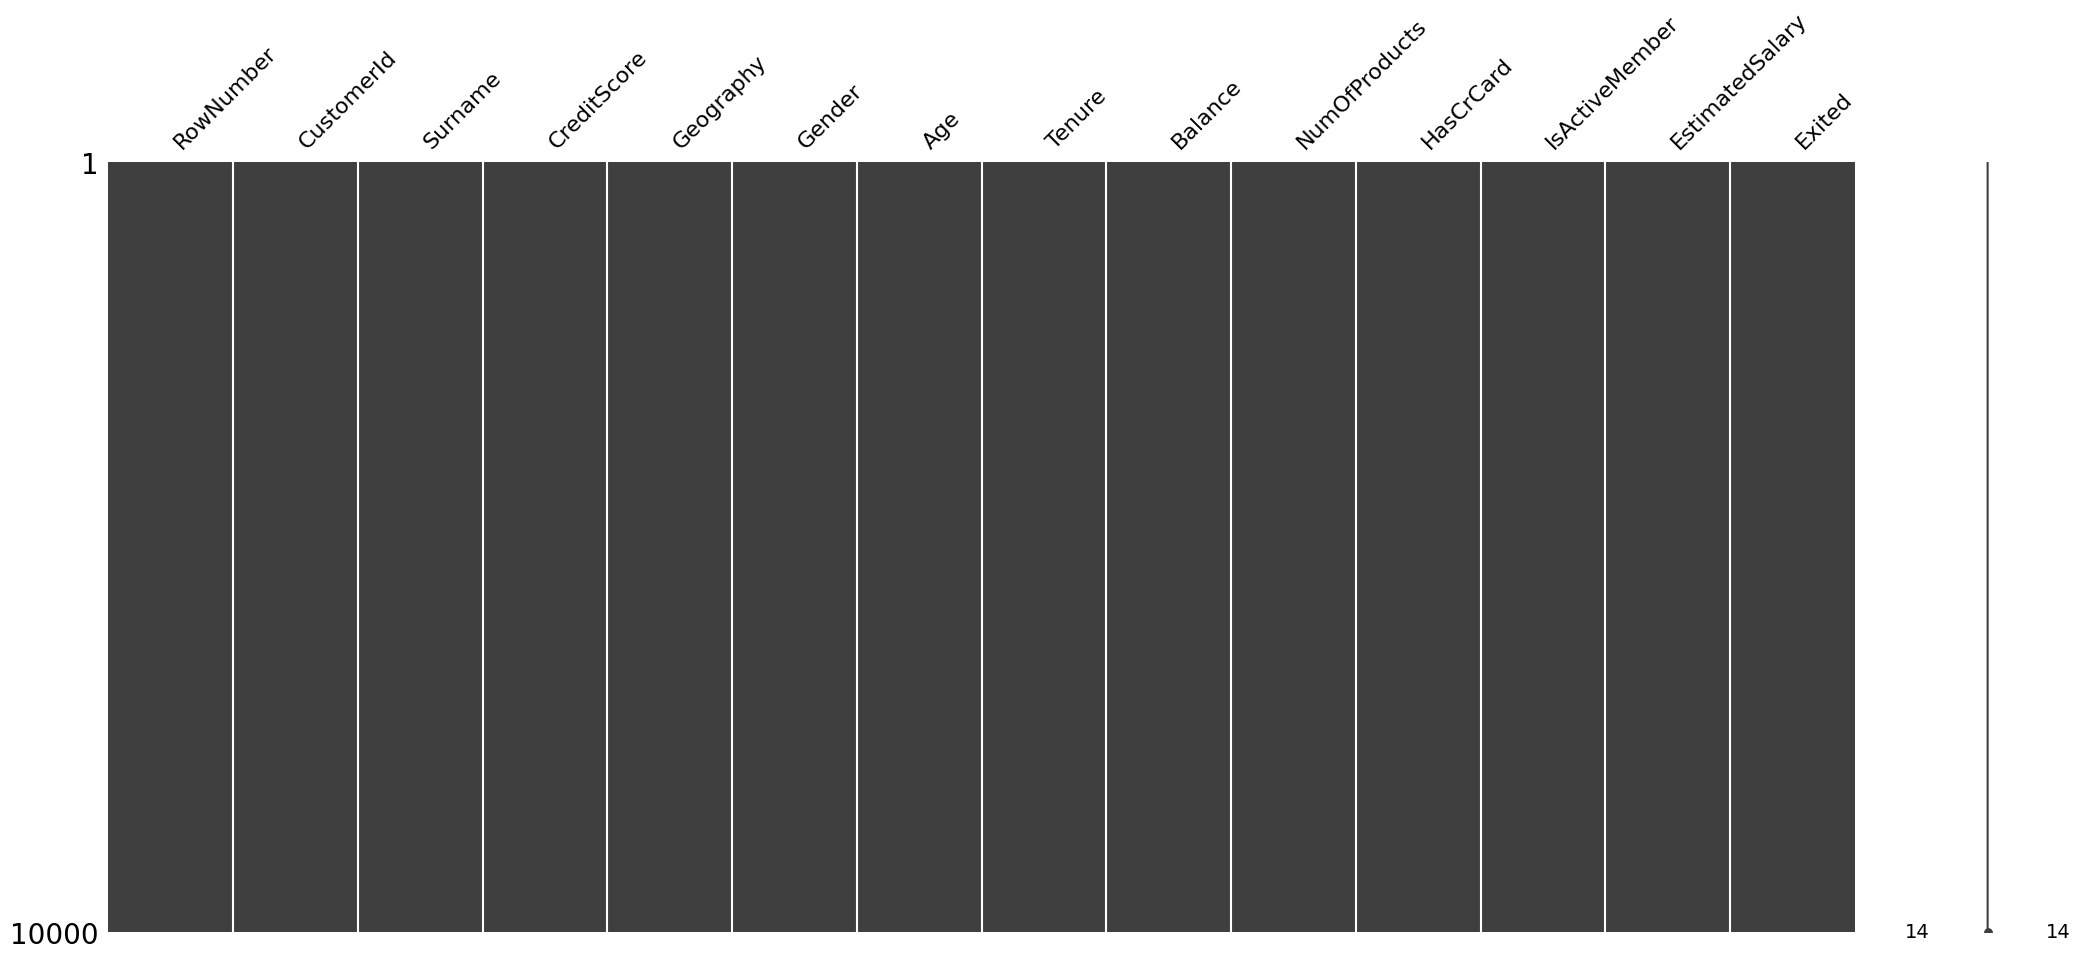

In [12]:
ms.matrix(dt)
plt.show()

In [13]:
dt.isnull().any()

RowNumber          False
CustomerId         False
Surname            False
CreditScore        False
Geography          False
Gender             False
Age                False
Tenure             False
Balance            False
NumOfProducts      False
HasCrCard          False
IsActiveMember     False
EstimatedSalary    False
Exited             False
dtype: bool

In [14]:
# duplicated valuez 

int(dt.duplicated().sum())

0

In [15]:
## check for skewness

dt.skew(numeric_only=True)

RowNumber          0.000000
CustomerId         0.001149
CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64

In [16]:
#  kurtosis
dt.kurt(numeric_only=True)

RowNumber         -1.200000
CustomerId        -1.196113
CreditScore       -0.425726
Age                1.395347
Tenure            -1.165225
Balance           -1.489412
NumOfProducts      0.582981
HasCrCard         -1.186973
IsActiveMember    -1.996747
EstimatedSalary   -1.181518
Exited             0.165671
dtype: float64

In [17]:
combined= pd.DataFrame({"skew":dt.skew(numeric_only=True),"Kurt":dt.kurt(numeric_only=True)})
print(combined)

                     skew      Kurt
RowNumber        0.000000 -1.200000
CustomerId       0.001149 -1.196113
CreditScore     -0.071607 -0.425726
Age              1.011320  1.395347
Tenure           0.010991 -1.165225
Balance         -0.141109 -1.489412
NumOfProducts    0.745568  0.582981
HasCrCard       -0.901812 -1.186973
IsActiveMember  -0.060437 -1.996747
EstimatedSalary  0.002085 -1.181518
Exited           1.471611  0.165671


In [18]:
dt.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [19]:
# checking unique in categorical columns 

In [20]:
columns=['Geography', 'Gender','HasCrCard','IsActiveMember','Exited']

for i in columns:
    print(i)
    print(dt[i].unique())
    print("_"*50)



Geography
['France' 'Spain' 'Germany']
__________________________________________________
Gender
['Female' 'Male']
__________________________________________________
HasCrCard
[1 0]
__________________________________________________
IsActiveMember
[1 0]
__________________________________________________
Exited
[1 0]
__________________________________________________


In [21]:
columns=['Geography', 'Gender','HasCrCard','IsActiveMember','Exited']

for i in columns:
    print(i)
    print(dt[i].nunique())
    print("_"*50)

Geography
3
__________________________________________________
Gender
2
__________________________________________________
HasCrCard
2
__________________________________________________
IsActiveMember
2
__________________________________________________
Exited
2
__________________________________________________


In [22]:
# value counts 
columns=['Geography', 'Gender','HasCrCard','IsActiveMember','Exited']

for i in columns:
    print(i)
    print(dt[i].value_counts())
    print("_ _"*25)

Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _
Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _
HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _
IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _
Exited
Exited
0    7963
1    2037
Name: count, dtype: int64
_ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ _


In [23]:
# checking ercentage if values in excited
dt['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [24]:
dt['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [25]:
# co relation 

corr=dt.corr(numeric_only=True)
corr

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


## DATA VISUALIZATION

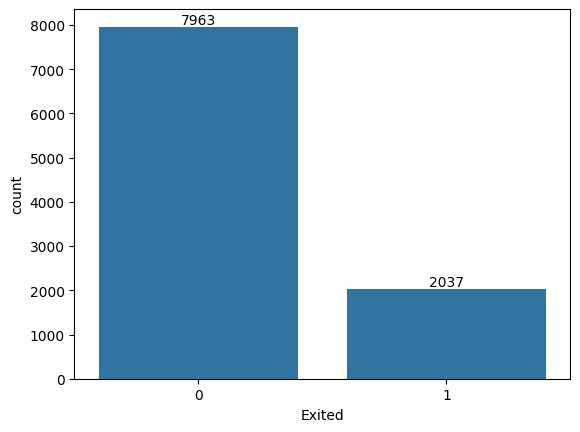

In [26]:
## bar plot vlue _counts 

ax=sns.barplot(dt["Exited"].value_counts())
for container in ax.containers:
    ax.bar_label(container)
plt.show()

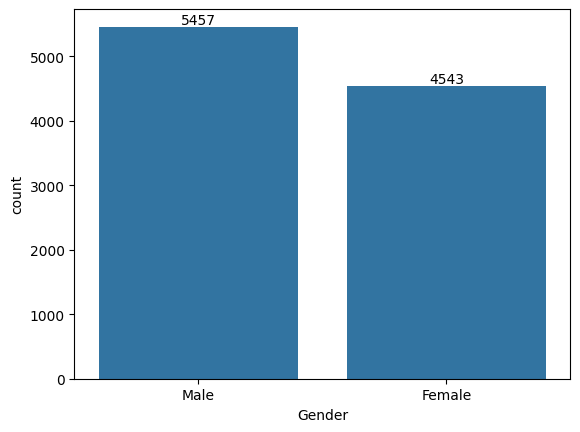

In [27]:
#gender
ax=sns.barplot(dt["Gender"].value_counts())
for container in ax.containers:
    ax.bar_label(container)
plt.show()

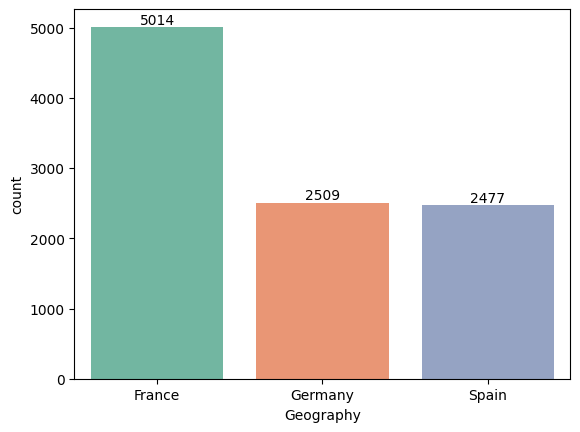

In [28]:
# for geography 
ax=sns.barplot(dt["Geography"].value_counts(),palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

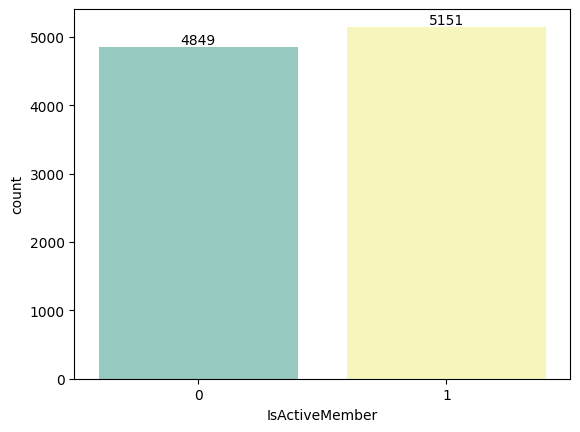

In [29]:
# Active member
ax=sns.barplot(dt["IsActiveMember"].value_counts(),palette='Set3')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

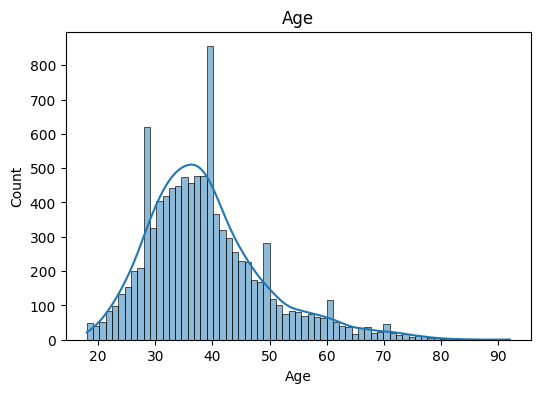

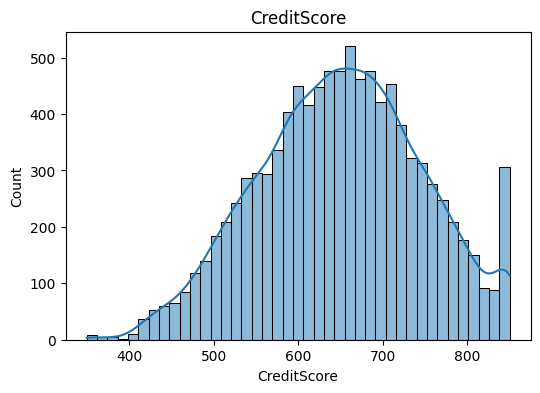

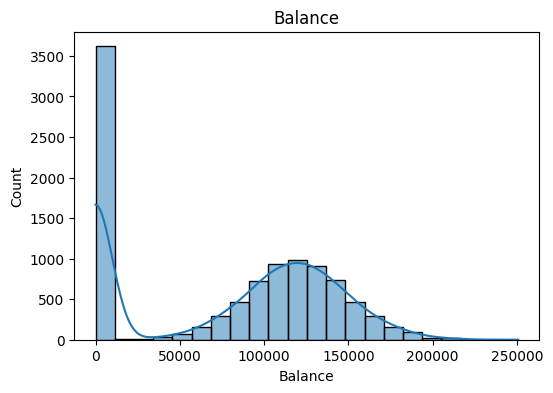

In [30]:
# age distribution plot 
columns=['Age','CreditScore','Balance']
for i in columns:
    plt.figure(figsize=(6,4))
    
    sns.histplot(dt[i],kde=True)
    plt.title(i)
plt.show()

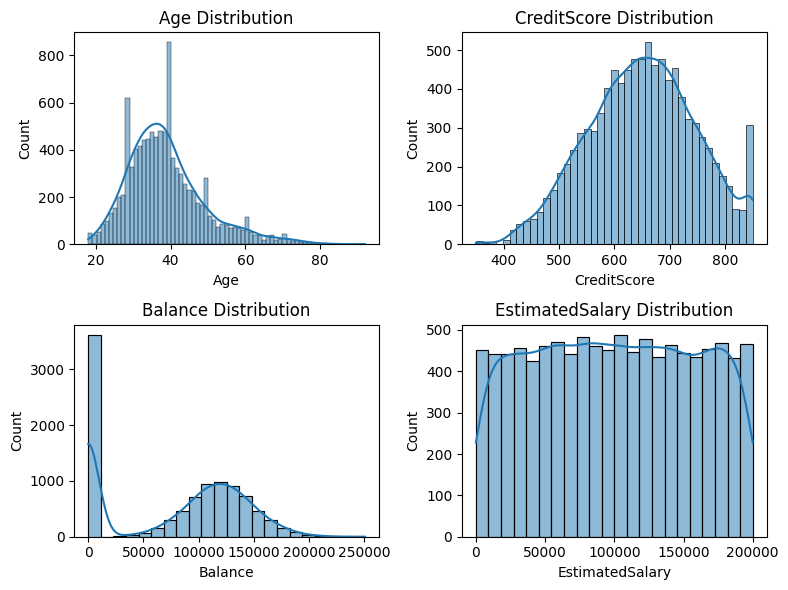

In [31]:
cols=['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

fig,axes=plt.subplots(2,2, figsize=(8,6))
axes=axes.flatten()

for i,col in enumerate (cols):
    sns.histplot(dt[col],kde=True,ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [32]:
# box plot for OUTLIER HANDLING 

In [33]:
len(dt.columns)

14

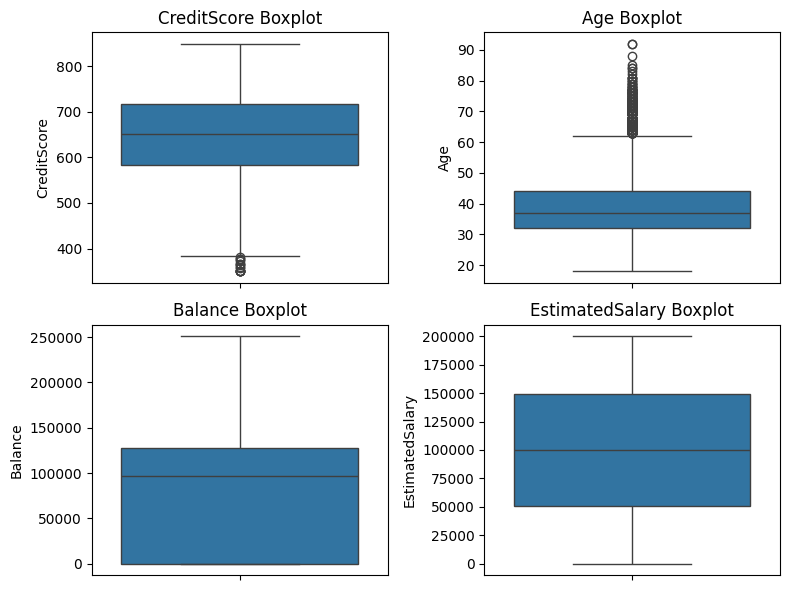

In [34]:
cols=['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

fig,axes=plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
for i,col in enumerate(cols):
    sns.boxplot(dt[col],ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')
plt.tight_layout()
plt.show()
                

In [35]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [36]:
# BI VARIATE ANALYSIS 

In [37]:
### NUMERICAL VS NUMERICAL VARIABLE 

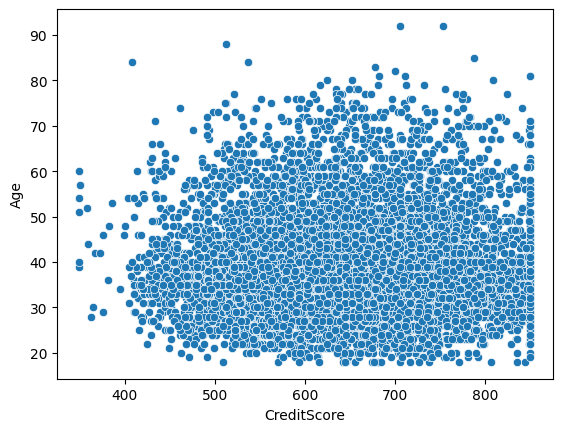

In [38]:
#credit score vs age 
sns.scatterplot(x=dt["CreditScore"],y=dt["Age"])
plt.show()

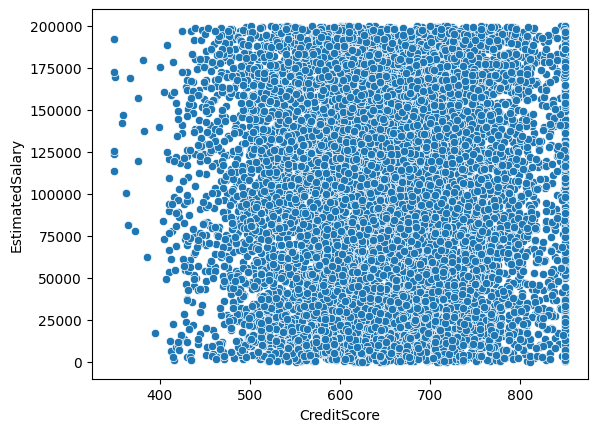

In [39]:
#credit scroe vs salary
sns.scatterplot(x=dt["CreditScore"],y=dt["EstimatedSalary"])
plt.show()

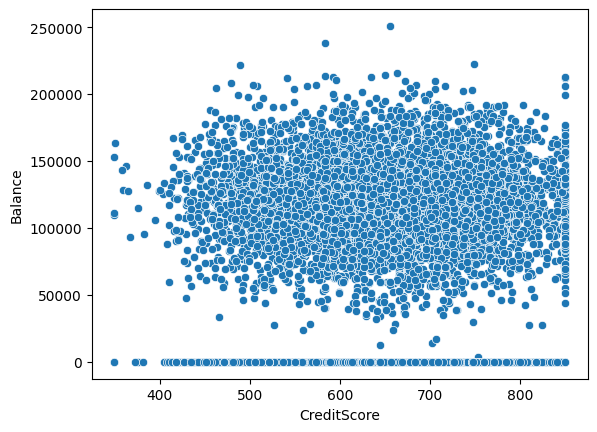

In [40]:
#credit scr=ore and balance 
sns.scatterplot(x=dt["CreditScore"],y=dt["Balance"])
plt.show()

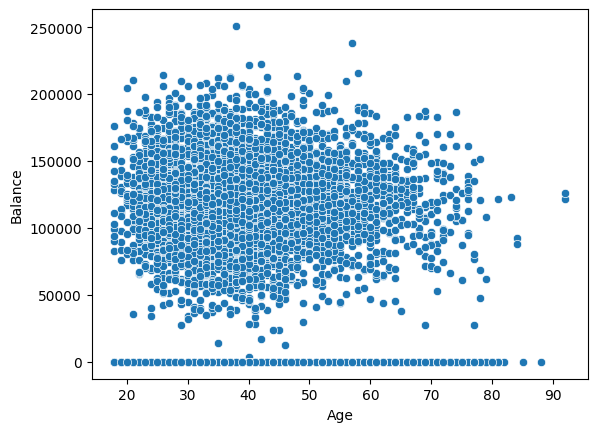

In [41]:
# AGE VS BALANCE 
sns.scatterplot(x=dt["Age"],y=dt["Balance"])
plt.show()

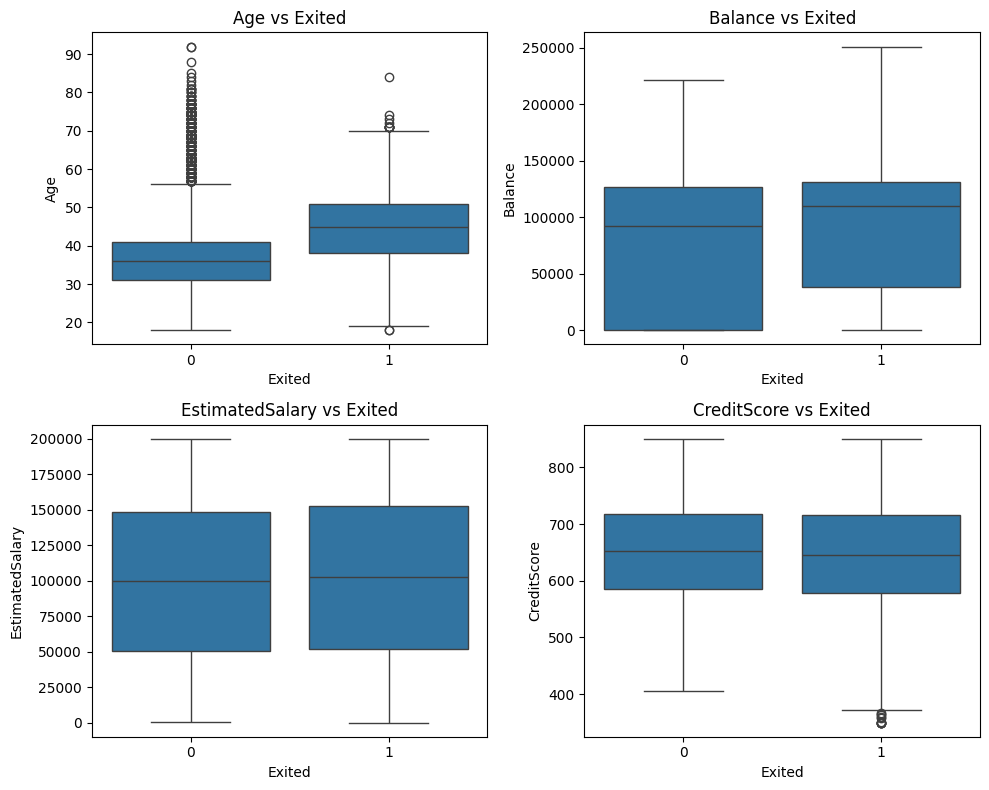

In [42]:
# relation with target 
#cols vs exited
cols=['Age', 'Balance', 'EstimatedSalary', 'CreditScore']

fig,axes=plt.subplots(2,2,figsize=(10,8))
axes=axes.flatten()

for i,col in enumerate(cols):
    sns.boxplot(x=dt["Exited"],y=dt[col],ax=axes[i])
    axes[i].set_title(f'{col} vs Exited')

plt.tight_layout()
plt.show()

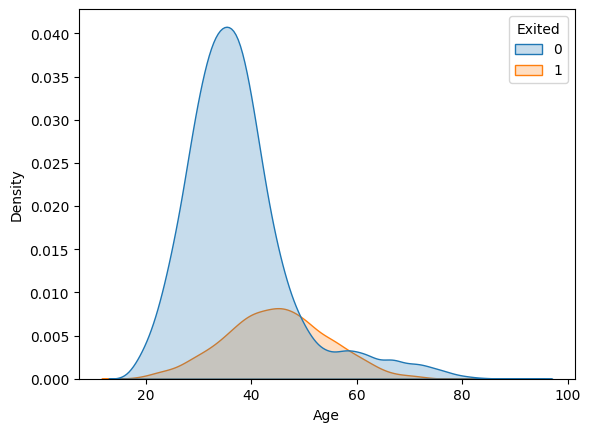

In [43]:
sns.kdeplot(data=dt, x='Age', hue='Exited', fill=True)
plt.show()

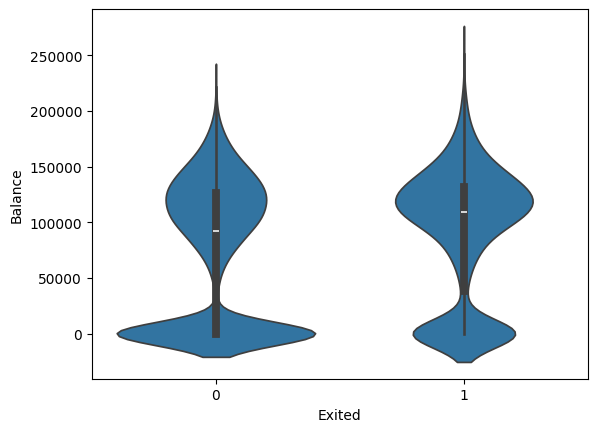

In [44]:
sns.violinplot(x=dt['Exited'], y=dt['Balance'])
plt.show()

In [45]:
# categorical relationship 
pd.crosstab(dt["Exited"],dt["Geography"])

Geography,France,Germany,Spain
Exited,,,
0,4204,1695,2064
1,810,814,413


## ENCODING VARIABLE /SKEW TREATMENT/OUTLIER REMOVAL

In [46]:
#Removing unwanted columns 

In [47]:
dt1=dt.copy()

In [48]:
dt1=dt1.drop(['RowNumber','CustomerId', 'Surname'],axis=1)

In [49]:
# ENCODING CATEGORICAL VARIABLE

In [50]:
dt1.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [51]:
# geography (one hot encoding
dt1=pd.get_dummies(dt1,columns=['Geography'],dtype=int)

# gender using map 
dt1["Gender"]=dt1["Gender"].map({"Male":1,"Female":0})

In [52]:
# skewness handling 

In [53]:
dt1.skew(numeric_only=True)

CreditScore         -0.071607
Gender              -0.183596
Age                  1.011320
Tenure               0.010991
Balance             -0.141109
NumOfProducts        0.745568
HasCrCard           -0.901812
IsActiveMember      -0.060437
EstimatedSalary      0.002085
Exited               1.471611
Geography_France    -0.005601
Geography_Germany    1.149340
Geography_Spain      1.169106
dtype: float64

In [54]:
dt1["Age_log"] = np.log1p(dt1["Age"])

dt1["NumOfProducts_log"] = np.log1p(dt1["NumOfProducts"])

In [55]:
dt1.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Age_log,NumOfProducts_log
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0,3.761200,0.693147
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1,3.737670,0.693147
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0,3.761200,1.386294
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0,3.688879,1.098612
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1,3.784190,0.693147


In [56]:
dt1=dt1.drop(columns=['Age','NumOfProducts'])

In [57]:
dt1.columns

Index(['CreditScore', 'Gender', 'Tenure', 'Balance', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Age_log', 'NumOfProducts_log'],
      dtype='object')

In [58]:
dt1_outlier=dt1.copy()

In [59]:
# OUTLIER TREATMENT 
cols=['CreditScore','Age_log',]

for col in cols:
    q1=dt1_outlier[col].quantile(0.25)
    q3=dt1_outlier[col].quantile(0.75)

    IQR= q3-q1

    lower=q1-1.5*IQR
    upper=q3+1.5*IQR

    print(f"{col}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print("-"*40)

    # capping 

    dt1_outlier[col]=np.where(dt1_outlier[col]>upper,upper,dt1_outlier[col])
    dt1_outlier[col]=np.where(dt1_outlier[col]<lower,lower,dt1_outlier[col])

CreditScore
Lower Bound: 383.0
Upper Bound: 919.0
----------------------------------------
Age_log
Lower Bound: 3.031275169010721
Upper Bound: 4.2718948822260785
----------------------------------------


#### Train Test Split for Standard scaling

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X=dt1_outlier.drop(columns="Exited")
y=dt1_outlier["Exited"]

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Standard Scaling

In [63]:
from sklearn.preprocessing import StandardScaler 

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   float64
 1   Gender             8000 non-null   int64  
 2   Tenure             8000 non-null   int64  
 3   Balance            8000 non-null   float64
 4   HasCrCard          8000 non-null   int64  
 5   IsActiveMember     8000 non-null   int64  
 6   EstimatedSalary    8000 non-null   float64
 7   Geography_France   8000 non-null   int64  
 8   Geography_Germany  8000 non-null   int64  
 9   Geography_Spain    8000 non-null   int64  
 10  Age_log            8000 non-null   float64
 11  NumOfProducts_log  8000 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 812.5 KB


In [65]:
num_cols=["CreditScore","Tenure","Balance","EstimatedSalary","Age_log","NumOfProducts_log"]

scaler= StandardScaler()

# copy
X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]=scaler.transform(X_test[num_cols])

In [66]:
# Feature selection

In [67]:
from sklearn.feature_selection import mutual_info_classif

In [68]:
mi_scores=mutual_info_classif(X_train_scaled,y_train)

In [69]:
mi_scores

array([0.        , 0.0038179 , 0.        , 0.01143073, 0.00608508,
       0.01054214, 0.00358926, 0.01004668, 0.01816249, 0.        ,
       0.07722065, 0.07685143])

In [70]:
mi_df=pd.DataFrame({"Feature":X_train_scaled.columns,"Mi score":mi_scores})
mi_df

,Feature,Mi score
0,CreditScore,0.000000
1,Gender,0.003818
2,Tenure,0.000000
3,Balance,0.011431
4,HasCrCard,0.006085
5,IsActiveMember,0.010542
6,EstimatedSalary,0.003589
7,Geography_France,0.010047
8,Geography_Germany,0.018162
9,Geography_Spain,0.000000


In [71]:
X_train_selected=X_train_scaled.drop(columns=["Tenure","HasCrCard"])
X_test_selected=X_test_scaled.drop(columns=["Tenure","HasCrCard"])

#### SMOTE

In [72]:
from imblearn.over_sampling import SMOTE

In [73]:
smote=SMOTE(sampling_strategy=0.45,random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(X_train_selected,y_train)

In [74]:
X_train_smote.columns

Index(['CreditScore', 'Gender', 'Balance', 'IsActiveMember', 'EstimatedSalary',
       'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Age_log',
       'NumOfProducts_log'],
      dtype='object')

In [75]:
X_train1=X_train_smote.copy()
y_train1=y_train_smote.copy()
X_test1=X_test_selected.copy()
y_test1=y_test.copy()

In [76]:
# Convert to NumPy arrays
X_train1 = X_train1.values
X_test1 = X_test1.values

y_train1 = y_train1.values
y_test1 = y_test1.values

## Modelling  Using ANN

In [77]:
# lets import all the necessary libraries

In [78]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("absl").setLevel(logging.ERROR)

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
import mlflow
import mlflow.tensorflow
from sklearn.metrics import (accuracy_score,confusion_matrix, classification_report)
from tensorflow.keras.callbacks import ModelCheckpoint


In [79]:
mlflow.set_tracking_uri("file:///C:/Users/Lenovo/Desktop/github%20projects/Assingment_ANN_CNN/customer%20churn/mlruns")
mlflow.set_experiment("ANN_Project")
# mlflow autolog
mlflow.tensorflow.autolog()


# model building and layer

model=Sequential()

# input layer and first Hidden Layer
model.add(Dense(32,activation='relu',input_shape=(X_train1.shape[1],)))

# Hidden Layer 2
model.add(Dense(16,activation='relu'))

#output layer 
model.add(Dense(1,activation='sigmoid'))

#compile model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#train model
with mlflow.start_run():
    hisory=model.fit(X_train1,y_train1,validation_split=0.2,epochs=50,batch_size=32,verbose=1)

    # test predictions
    y_test_pred =model.predict(X_test1)
    y_test_pred = (y_test_pred > 0.5).astype(int)
    
     # Flatten predictions
    y_test_pred = y_test_pred.ravel()
    accuracy_test=accuracy_score(y_test1,y_test_pred)
    mlflow.log_metric("Test_Accuracy",accuracy_test)
    print("Test_acuracy",accuracy_test)
    print("--"*25)
    
    
    #Train Predictions
    y_train_pred=model.predict(X_train1)
    y_train_pred=(y_train_pred>0.5).astype(int)

    
    # Flatten predictions
    y_train_pred = y_train_pred.ravel()
    accuracy_train=accuracy_score(y_train1,y_train_pred)
    mlflow.log_metric("Accuracy_Train",accuracy_train)
    print("TrainAccuracy", accuracy_train)
    print("--"*25)
    
    
    #confusion matrix
    cm=confusion_matrix(y_test1,y_test_pred)
    print("Confusion_Matrix",cm)
    print("--"*25)

    
   ## mlflow saving 
    with open ("Confusion_Matrix.txt",'w') as f:
        f.write(str(cm))
    mlflow.log_artifact("Confusion_Matrix.txt")

    #classification report
    report=classification_report(y_test1,y_test_pred)
    print("Classification Report")
    print(report)
    print("--"*25)

# ml flow saving 
    with open ("Classification_report.txt",'w') as f:
        f.write(str(report))
    mlflow.log_artifact("Classification_report.txt")
                                 
    
    

    

Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7668 - loss: 0.5187 - val_accuracy: 0.3829 - val_loss: 0.9745
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8188 - loss: 0.4151 - val_accuracy: 0.5206 - val_loss: 0.8294
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8326 - loss: 0.3892 - val_accuracy: 0.5916 - val_loss: 0.7573
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8412 - loss: 0.3741 - val_accuracy: 0.5927 - val_loss: 0.7524
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8475 - loss: 0.3629 - val_accuracy: 0.6128 - val_loss: 0.7288
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8524 - loss: 0.3562 - val_accuracy: 0.6421 - val_loss: 0.6862
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8551 - loss: 0.3505 - val_accuracy: 0.5857 - val_loss: 0.7764
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8561 - loss: 0.3466 - val_accuracy: 0.

2026/05/18 12:20:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test_acuracy 0.8645
--------------------------------------------------
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
TrainAccuracy 0.8310546875
--------------------------------------------------
Confusion_Matrix [[1540   67]
 [ 204  189]]
--------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

--------------------------------------------------


#### Model 2 :Apply the dropout regularization and early stopping techniques to improve model performance

In [80]:

## ml flow 
mlflow.set_tracking_uri("file:///C:/Users/Lenovo/Desktop/github%20projects/Assingment_ANN_CNN/customer%20churn/mlruns")
mlflow.set_experiment("ANN_Project")

# mlflow autolog
mlflow.tensorflow.autolog()

# Early Stopping 
early_stopping=EarlyStopping(monitor='val_loss',patience=15,min_delta=0.005,restore_best_weights=True,verbose=True)

# Model Checkpoint 
checkpoint=ModelCheckpoint(filepath="C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras",
monitor="val_loss",save_best_only=True,verbose=1)

# model building and layer

model=Sequential()

# Input layer and first Hidden Layer
model.add(Dense(32,activation='relu',input_shape=(X_train1.shape[1],)))

# Dropout Layer 
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(16,activation='relu'))

#Dropout Layer
model.add(Dropout(0.2))
#output layer 
model.add(Dense(1,activation='sigmoid'))

#compile model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#train model
with mlflow.start_run():
    history=model.fit(X_train1,y_train1,validation_split=0.2,epochs=50,batch_size=32,verbose=1,callbacks=[early_stopping,checkpoint])

    # test predictions
    y_test_pred =model.predict(X_test1)
    y_test_pred = (y_test_pred > 0.5).astype(int)
     # Flatten predictions
    y_test_pred = y_test_pred.ravel()
    accuracy_test=accuracy_score(y_test1,y_test_pred)
    mlflow.log_metric("Test_Accuracy",accuracy_test)
    print("Test_acuracy",accuracy_test)
    print("--"*25)
    
    #Train Predictions
    y_train_pred=model.predict(X_train1)
    y_train_pred=(y_train_pred>0.5).astype(int)
        # Flatten predictions
    y_train_pred = y_train_pred.ravel()
    accuracy_train=accuracy_score(y_train1,y_train_pred)
    mlflow.log_metric("Accuracy_Train",accuracy_train)
    print("TrainAccuracy", accuracy_train)
    print("--"*25)
    
    #confusion matrix
    cm=confusion_matrix(y_test1,y_test_pred)
    print("Confusion_Matrix",cm)
    print("--"*25)
## mlflow saving 
    with open ("Confusion_Matrix.txt",'w') as f:
        f.write(str(cm))
    mlflow.log_artifact("Confusion_Matrix.txt")

    #classification report
    report=classification_report(y_test1,y_test_pred)
    print("Classification Report")
    print(report)
    print("--"*25)

# ml flow saving 
    with open ("Classification_report.txt",'w') as f:
        f.write(str(report))
    mlflow.log_artifact("Classification_report.txt")

Epoch 1/50
226/231 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.5889
Epoch 1: val_loss improved from None to 0.97056, saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras

Epoch 1: finished saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7655 - loss: 0.5134 - val_accuracy: 0.3650 - val_loss: 0.9706
Epoch 2/50
224/231 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7955 - loss: 0.4602
Epoch 2: val_loss improved from 0.97056 to 0.90266, saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras

Epoch 2: finished saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8067 - loss: 0.4445 - val_accuracy: 0.4322 - 

2026/05/18 12:22:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test_acuracy 0.862
--------------------------------------------------
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step
TrainAccuracy 0.8194444444444444
--------------------------------------------------
Confusion_Matrix [[1550   57]
 [ 219  174]]
--------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.44      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000

--------------------------------------------------


In [81]:
from tensorflow.keras.models import load_model


In [82]:
best_model = load_model(
    "C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras"
)

In [83]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,796 (7.02 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 899 (3.52 KB)

In [84]:
weights = best_model.get_weights()

weights

[array([[ 4.53110635e-02,  7.01836199e-02, -8.03811476e-02,
          1.86843146e-02,  7.71485269e-02,  6.51973998e-03,
         -8.39284509e-02, -1.89705901e-02, -5.75486608e-02,
          1.18955933e-02, -1.50101781e-01,  6.21693172e-02,
         -4.04718481e-02, -4.15168889e-02,  2.93315966e-02,
         -4.68966775e-02,  9.24071670e-02,  2.24444382e-02,
          8.67248327e-02, -2.45984700e-02, -2.86352132e-02,
         -1.05531745e-01, -4.90986034e-02,  1.64271578e-01,
          3.00684832e-02,  8.31839368e-02, -5.15775643e-02,
         -5.57017811e-02,  3.66526321e-02, -1.09846913e-03,
         -7.30705112e-02, -2.26484593e-02],
        [-3.43328528e-02,  2.89610177e-01,  3.13921273e-02,
          1.47430241e-01,  1.70841053e-01,  2.82234311e-01,
         -1.30069673e-01,  1.61734577e-02, -6.66436702e-02,
         -1.66224107e-01, -3.81677866e-01,  3.53941709e-01,
         -7.10951909e-02,  1.53322458e-01, -1.19234979e-01,
         -6.33500889e-02,  1.05365507e-01, -4.00226265e-

### MODEL 3: Applying keras tuner and finding Best Model

In [85]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

In [86]:
mlflow.set_tracking_uri( "file:///C:/Users/Lenovo/Desktop/github%20projects/Assingment_ANN_CNN/customer%20churn/mlruns")
mlflow.set_experiment("ANN_Project")

# model building 

def build_model(hp):
    model=Sequential()

    # input 

    model.add(Dense(units=hp.Int("units_input",16,128,step=16),activation='relu',input_shape=(X_train1.shape[1],)))

    #dropout
    model.add(Dropout(hp.Float("dropout_input",0.1,0.5,step=0.1)))

    #hidden layer 

    for i in range(hp.Int("num_hidden_layers",1,3)):
        model.add(Dense(units=hp.Int(f'units_{i}',16,128,step=16),activation= 'relu'))

        model.add(Dropout(hp.Float(f"Dropout_{i}",0.1,0.5,step=0.1)))

    #output
    model.add(Dense(1,activation="sigmoid"))

    #Learning Rate 
    learning_rate=hp.Choice("learning_rate",values=[0.01,0.001,0.0001])

    # compile 
    model.compile(optimizer=Adam(learning_rate=learning_rate),loss='binary_crossentropy',metrics=['accuracy'])

    return model

    #initilize Tuner

tuner=kt.RandomSearch(build_model,objective='val_accuracy',max_trials=10,executions_per_trial=1,
                          directory='keras_tuner_dir',project_name="customer_churn_ann")

    #Early Stopping
early_stopping =EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

    #Hyperparameter
tuner.search(X_train1,y_train1,validation_split=0.2,epochs=50,batch_size=32,callbacks=[early_stopping])

    ## best hyper parameter 

best_hp=tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

    #building best model 
best_model=tuner.hypermodel.build(best_hp)

    #model checkpoint
checkpoint=ModelCheckpoint(filepath="C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras",
monitor='val_loss',save_best_only=True,verbose=1)

    #ML Flow Training 
with mlflow.start_run():
    mlflow.tensorflow.autolog()

    history =best_model.fit(X_train1,y_train1,validation_split=0.2,epochs=50,batch_size=32,
                                callbacks=[early_stopping,checkpoint],verbose=1)

        # predictions 

    y_test_pred=best_model.predict(X_test1)
    y_test_pred=(y_test_pred>0.5).astype(int)
    y_test_pred=y_test_pred.ravel()

    test_accuracy=accuracy_score(y_test1,y_test_pred)
    print("Test_accuracy",test_accuracy)

    mlflow.log_metric("Test_Accuracy",test_accuracy)

        #train predictions
    y_train_pred=best_model.predict(X_train1)
    y_train_pred=(y_train_pred>0.5).astype(int)
    y_train_pred=y_train_pred.ravel()

    accuracy_train= accuracy_score(y_train1,y_train_pred)
    print("Train_accuracy",accuracy_train)

    mlflow.log_metric("Train_accuracy",accuracy_train)

        #confusion_matrix

    cm=confusion_matrix(y_test1,y_test_pred)
    print("Confusion_matrix")
    print(cm)

    with open ("Confusion_Matrix.txt","w") as f :
         f.write(str(cm))

    mlflow.log_artifact("Confusion_matrix.txt")

        # classification_report
    report= classification_report(y_test1,y_test_pred)
    print("Classification_report")
    print(report)

    with open("Classification_report.txt","w") as f:
        f.write(str(report))

    mlflow.log_artifact("Classification_report.txt")
              










        

Reloading Tuner from keras_tuner_dir\customer_churn_ann\tuner0.json
{'units_input': 64, 'dropout_input': 0.2, 'num_hidden_layers': 3, 'units_0': 48, 'Dropout_0': 0.4, 'learning_rate': 0.001, 'units_1': 128, 'Dropout_1': 0.1, 'units_2': 128, 'Dropout_2': 0.4}


Epoch 1/50
224/231 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7954 - loss: 0.4987
Epoch 1: val_loss improved from None to 0.82219, saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras

Epoch 1: finished saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7998 - loss: 0.4713 - val_accuracy: 0.4615 - val_loss: 0.8222
Epoch 2/50
227/231 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8092 - loss: 0.4425
Epoch 2: val_loss improved from 0.82219 to 0.68725, saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras

Epoch 2: finished saving model to C:/Users/Lenovo/Desktop/github projects/Assingment_ANN_CNN/customer churn/models/best_ann_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8211 - loss: 0.4216 - val_accuracy: 0.6573 -

2026/05/18 12:23:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test_accuracy 0.8635
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test_accuracy 0.8333333333333334
Confusion_matrix
[[1525   82]
 [ 191  202]]
Classification_report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.71      0.51      0.60       393

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000

